In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import datetime
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate
from tensorflow.keras.models import Model

In [10]:
#read CSV file
production_df=pd.read_csv("../Data Processing/combined_output.csv")
process_df=pd.read_csv("../Data Processing/combined_output_proc.csv")

In [3]:
# Convert the 'Date' column to datetime format
#production_df['Date'] = pd.to_datetime(production_df['Date'], format='%d/%m/%Y')
#process_df['Date'] = pd.to_datetime(process_df['Date'], format='%d/%m/%Y')




In [11]:
columns=process_df.columns
columns

Index(['Status', 'Part', 'Process', 'Employee', 'Date', 'Time', 'AV Wash',
       'VYA - Batch', 'VFX - Yeast Vat', 'Code', 'VFX - Feed TS',
       'VFX - Feed SS', 'VFX - Feed IS', 'VFX - Feed Setting',
       'VFX - Beer Recycle Setting', 'VFX - Water Setting', 'VFX - Cream TS',
       'VFX - Cream SS', 'VFX - Cream IS', 'VYA - Papain Batch',
       'VYA - Papain added', 'VYA - Clerol batch', 'VYA - Vaccum Salt Added',
       'VYA - Bag Salt Batch', 'VYA - Bag Salt Added', 'VYA - 1st pH',
       'VYA - Post heat duration', 'VYA - Final Volume', 'VMBX - Auto TS',
       'VMBX - Auto SS', 'VMBX - Auto IS', 'VMBX - Auto Yield',
       'VMBX - Auto Feed', 'VMBX - Water Rate', 'VMBX - Res Recycle',
       'VMBX - Ext Flowrate', 'VMBX - Ext TS', 'VMBX - Ext SS',
       'VMBX - Ext IS', 'VMBX - Res TS', 'VMBX - Res SS', 'VMBX - Res IS',
       'VMBX - H.Residue TS', 'VMBX - H.Residue SS', 'VMBX - H.Residue IS',
       'VMBX - RISC%', 'VMBX - Res Vat', 'Code.1', 'VMBX - Res Batch',
       'V

In [12]:
# Combine "Date" and "Time" into a single datetime column
production_df['Datetime'] = pd.to_datetime(production_df['Date'] + ' ' + production_df['Time'], format='%d/%m/%Y %H:%M:%S')

# Round the time to the nearest hour to group by hour
production_df['Datetime'] = production_df['Datetime'].dt.floor('h')

# Pivot the table so that each product type appears as a column, with the corresponding yeast weight
production_pivot_df = production_df.pivot_table(index='Datetime', columns='Part', values='VYP - Yeast Weight', aggfunc='sum').reset_index()

# Display the result to the user
production_pivot_df.head(10)

Part,Datetime,Yeast - BRD,Yeast - BRN,Yeast - FMX
0,2019-10-29 02:00:00,1257.50,NaN,NaN
1,2019-10-29 03:00:00,789.00,NaN,NaN
2,2019-10-29 04:00:00,1103.50,NaN,NaN
3,2019-10-29 05:00:00,638.75,NaN,NaN
4,2019-10-29 07:00:00,618.50,NaN,NaN
5,2019-10-29 08:00:00,1248.75,NaN,NaN
6,2019-10-29 09:00:00,611.50,NaN,NaN
7,2019-10-29 10:00:00,1242.00,NaN,NaN
8,2019-10-29 11:00:00,623.75,NaN,NaN
9,2019-10-29 12:00:00,627.75,NaN,152.5


In [13]:
process_df.columns

Index(['Status', 'Part', 'Process', 'Employee', 'Date', 'Time', 'AV Wash',
       'VYA - Batch', 'VFX - Yeast Vat', 'Code', 'VFX - Feed TS',
       'VFX - Feed SS', 'VFX - Feed IS', 'VFX - Feed Setting',
       'VFX - Beer Recycle Setting', 'VFX - Water Setting', 'VFX - Cream TS',
       'VFX - Cream SS', 'VFX - Cream IS', 'VYA - Papain Batch',
       'VYA - Papain added', 'VYA - Clerol batch', 'VYA - Vaccum Salt Added',
       'VYA - Bag Salt Batch', 'VYA - Bag Salt Added', 'VYA - 1st pH',
       'VYA - Post heat duration', 'VYA - Final Volume', 'VMBX - Auto TS',
       'VMBX - Auto SS', 'VMBX - Auto IS', 'VMBX - Auto Yield',
       'VMBX - Auto Feed', 'VMBX - Water Rate', 'VMBX - Res Recycle',
       'VMBX - Ext Flowrate', 'VMBX - Ext TS', 'VMBX - Ext SS',
       'VMBX - Ext IS', 'VMBX - Res TS', 'VMBX - Res SS', 'VMBX - Res IS',
       'VMBX - H.Residue TS', 'VMBX - H.Residue SS', 'VMBX - H.Residue IS',
       'VMBX - RISC%', 'VMBX - Res Vat', 'Code.1', 'VMBX - Res Batch',
       'V

In [14]:

# Combine "Date" and "Time" into a single datetime column
process_df['Datetime'] = pd.to_datetime(process_df['Date'] + ' ' + process_df['Time'], format='%d/%m/%Y %H:%M:%S')

# Round the time to the nearest hour
process_df['Datetime'] = process_df['Datetime'].dt.floor('h')

# Select the relevant columns: Part, Datetime, and the production metrics
relevant_columns = ['Datetime', 'Part', 'VMBX - Auto Yield', 'VMBX - Auto Feed', 'VYA - Papain added',
 'VYA - Final Volume', 'VFX - Feed SS', 'VMBX - Res IS/TS (%)']
# Filter the dataframe for these columns
process_df_filtered = process_df[relevant_columns]

# Pivot the table to have one column per product for each metric
pivot_yield = process_df_filtered.pivot_table(index='Datetime', columns='Part', values='VMBX - Auto Yield', aggfunc='sum').reset_index()
pivot_vmbxfeed = process_df_filtered.pivot_table(index='Datetime', columns='Part', values='VMBX - Auto Feed', aggfunc='sum').reset_index()
pivot_papain = process_df_filtered.pivot_table(index='Datetime', columns='Part', values='VYA - Papain added', aggfunc='mean').reset_index()
pivot_vol = process_df_filtered.pivot_table(index='Datetime', columns='Part', values='VYA - Final Volume', aggfunc='sum').reset_index()
pivot_vfxfeed = process_df_filtered.pivot_table(index='Datetime', columns='Part', values='VFX - Feed SS', aggfunc='sum').reset_index()
pivot_ists = process_df_filtered.pivot_table(index='Datetime', columns='Part', values='VMBX - Res IS/TS (%)', aggfunc='mean').reset_index()

# Merge the three pivoted dataframes on the Datetime
process_merged_df = pd.merge(pivot_yield, pivot_vmbxfeed, on='Datetime', suffixes=('_Yield', '_VMBX_Feed'))
process_merged_df = pd.merge(process_merged_df, pivot_papain, on='Datetime', suffixes=('', '_Papain'))
process_merged_df = pd.merge(process_merged_df, pivot_vol, on='Datetime', suffixes=('', '_Volume'))
process_merged_df = pd.merge(process_merged_df, pivot_vfxfeed, on='Datetime', suffixes=('', '_VFX_Feed'))
process_merged_df = pd.merge(process_merged_df, pivot_ists, on='Datetime', suffixes=('', '_IS/TS'))

# Rename the columns by adding '_proc' to the columns 'Yeast - BRD', 'Yeast - BRN', 'Yeast - FMX'
process_merged_df = process_merged_df.rename(columns={
    'Yeast - BRD': 'Yeast - BRD_Papain',
    'Yeast - BRN': 'Yeast - BRN_Papain',
    'Yeast - FMX': 'Yeast - FMX_Papain'
})
# Keep only the columns of interest
columns_to_keep = ['Datetime', 'Yeast - BRD_Yield', 'Yeast - BRD_VMBX_Feed', 'Yeast - BRD_Papain', 'Yeast - BRD_Volume', 
                   'Yeast - BRD_VFX_Feed', 'Yeast - BRD_IS/TS', 'Yeast - BRN_Yield', 'Yeast - BRN_VMBX_Feed', 'Yeast - BRN_Papain', 'Yeast - BRN_Volume', 
                   'Yeast - BRN_VFX_Feed', 'Yeast - BRN_IS/TS', 'Yeast - FMX_Yield', 'Yeast - FMX_VMBX_Feed', 'Yeast - FMX_Papain', 'Yeast - FMX_Volume', 
                   'Yeast - FMX_VFX_Feed', 'Yeast - FMX_IS/TS']

# Filter the dataframe to keep only the necessary columns
process_filtered_df = process_merged_df[columns_to_keep]


# Display the updated dataframe
process_filtered_df.head()


Part,Datetime,Yeast - BRD_Yield,Yeast - BRD_VMBX_Feed,Yeast - BRD_Papain,Yeast - BRD_Volume,Yeast - BRD_VFX_Feed,Yeast - BRD_IS/TS,Yeast - BRN_Yield,Yeast - BRN_VMBX_Feed,Yeast - BRN_Papain,Yeast - BRN_Volume,Yeast - BRN_VFX_Feed,Yeast - BRN_IS/TS,Yeast - FMX_Yield,Yeast - FMX_VMBX_Feed,Yeast - FMX_Papain,Yeast - FMX_Volume,Yeast - FMX_VFX_Feed,Yeast - FMX_IS/TS
0,2019-09-30 11:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.61,11000.0,2.1,20200.0,3.22,80.17,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-09-30 13:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.61,11500.0,2.0,19800.0,3.22,80.98,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-09-30 15:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.61,12000.0,1.9,18400.0,3.22,80.79,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-10-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.69,11000.0,4.0,19900.0,0.0,80.940
4,2019-10-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.38,22000.0,3.0,37300.0,0.0,80.215


In [15]:
pivot_papain

Part,Datetime,Yeast - BRD,Yeast - BRN,Yeast - FMX
0,2019-09-30 11:00:00,NaN,2.1,NaN
1,2019-09-30 13:00:00,NaN,2.0,NaN
2,2019-09-30 15:00:00,NaN,1.9,NaN
3,2019-10-01 01:00:00,NaN,NaN,4.0
4,2019-10-01 02:00:00,NaN,NaN,3.0
...,...,...,...,...
747,2020-06-30 01:00:00,NaN,NaN,4.0
748,2020-06-30 09:00:00,NaN,NaN,5.6
749,2020-06-30 10:00:00,NaN,NaN,5.6
750,2020-06-30 13:00:00,NaN,NaN,4.0


In [16]:
process_merged_df

Part,Datetime,Yeast - BRD_Yield,Yeast - BRN_Yield,Yeast - FMX_Yield,Yeast - BRD_VMBX_Feed,Yeast - BRN_VMBX_Feed,Yeast - FMX_VMBX_Feed,Yeast - BRD_Papain,Yeast - BRN_Papain,Yeast - FMX_Papain,Yeast - BRD_Volume,Yeast - BRN_Volume,Yeast - FMX_Volume,Yeast - BRD_VFX_Feed,Yeast - BRN_VFX_Feed,Yeast - FMX_VFX_Feed,Yeast - BRD_IS/TS,Yeast - BRN_IS/TS,Yeast - FMX_IS/TS
0,2019-09-30 11:00:00,NaN,0.61,NaN,NaN,11000.0,NaN,NaN,2.1,NaN,NaN,20200.0,NaN,NaN,3.22,NaN,NaN,80.17,NaN
1,2019-09-30 13:00:00,NaN,0.61,NaN,NaN,11500.0,NaN,NaN,2.0,NaN,NaN,19800.0,NaN,NaN,3.22,NaN,NaN,80.98,NaN
2,2019-09-30 15:00:00,NaN,0.61,NaN,NaN,12000.0,NaN,NaN,1.9,NaN,NaN,18400.0,NaN,NaN,3.22,NaN,NaN,80.79,NaN
3,2019-10-01 01:00:00,NaN,NaN,0.69,NaN,NaN,11000.0,NaN,NaN,4.0,NaN,NaN,19900.0,NaN,NaN,0.0,NaN,NaN,80.940
4,2019-10-01 02:00:00,NaN,NaN,1.38,NaN,NaN,22000.0,NaN,NaN,3.0,NaN,NaN,37300.0,NaN,NaN,0.0,NaN,NaN,80.215
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721,2020-06-30 01:00:00,NaN,NaN,0.68,NaN,NaN,8600.0,NaN,NaN,4.0,NaN,NaN,19400.0,NaN,NaN,0.0,NaN,NaN,89.740
722,2020-06-30 09:00:00,NaN,NaN,0.68,NaN,NaN,8600.0,NaN,NaN,5.6,NaN,NaN,20000.0,NaN,NaN,0.0,NaN,NaN,89.600
723,2020-06-30 10:00:00,NaN,NaN,0.68,NaN,NaN,6500.0,NaN,NaN,5.6,NaN,NaN,20101.0,NaN,NaN,0.0,NaN,NaN,91.480
724,2020-06-30 13:00:00,NaN,NaN,0.66,NaN,NaN,6800.0,NaN,NaN,4.0,NaN,NaN,14954.0,NaN,NaN,0.0,NaN,NaN,92.960


In [23]:


# Merge the production and the process files
merged_df = pd.merge(process_filtered_df,production_pivot_df,  on='Datetime')




In [24]:
merged_df

Part,Datetime,Yeast - BRD_Yield,Yeast - BRD_VMBX_Feed,Yeast - BRD_Papain,Yeast - BRD_Volume,Yeast - BRD_VFX_Feed,Yeast - BRD_IS/TS,Yeast - BRN_Yield,Yeast - BRN_VMBX_Feed,Yeast - BRN_Papain,...,Yeast - BRN_IS/TS,Yeast - FMX_Yield,Yeast - FMX_VMBX_Feed,Yeast - FMX_Papain,Yeast - FMX_Volume,Yeast - FMX_VFX_Feed,Yeast - FMX_IS/TS,Yeast - BRD,Yeast - BRN,Yeast - FMX
0,2019-10-29 05:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.41,16560.0,4.8,38500.0,0.0,84.37,638.75,NaN,NaN
1,2019-10-29 07:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.71,8460.0,3.0,14700.0,0.0,85.14,618.50,NaN,NaN
2,2019-10-29 09:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.70,8400.0,3.0,18000.0,0.0,83.36,611.50,NaN,NaN
3,2019-10-29 11:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.70,8562.0,3.0,18050.0,0.0,83.91,623.75,NaN,NaN
4,2019-10-30 02:00:00,1.74,21577.0,1.8,56066.0,10.53,88.683333,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1394.25,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,2020-06-29 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.70,8600.0,4.0,19900.0,0.0,98.93,NaN,NaN,1220.0
302,2020-06-30 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.68,8600.0,4.0,19400.0,0.0,89.74,NaN,NaN,610.0
303,2020-06-30 09:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.68,8600.0,5.6,20000.0,0.0,89.60,NaN,611.00,NaN
304,2020-06-30 10:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.68,6500.0,5.6,20101.0,0.0,91.48,NaN,459.00,NaN


In [25]:
# Set the 'Datetime' column as the index (if not already set)
merged_df['Datetime'] = pd.to_datetime(merged_df['Datetime'])  # Ensure the Datetime column is in datetime format
merged_df.set_index('Datetime', inplace=True)

#Save the result to a new CSV file
output_file = "../Data Processing/daily_sum_weight_merg_2.csv"
merged_df.to_csv(output_file, index=True)


<Figure size 1000x600 with 0 Axes>

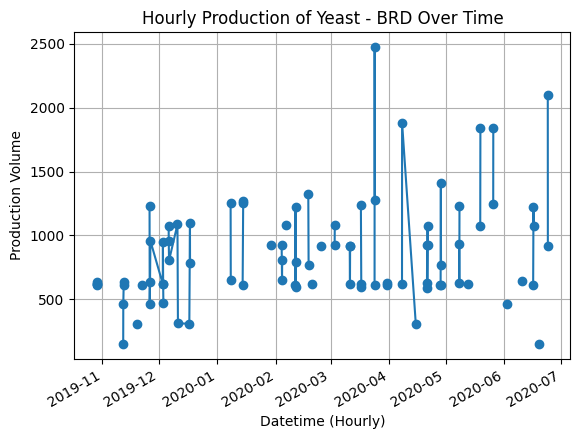

<Figure size 1000x600 with 0 Axes>

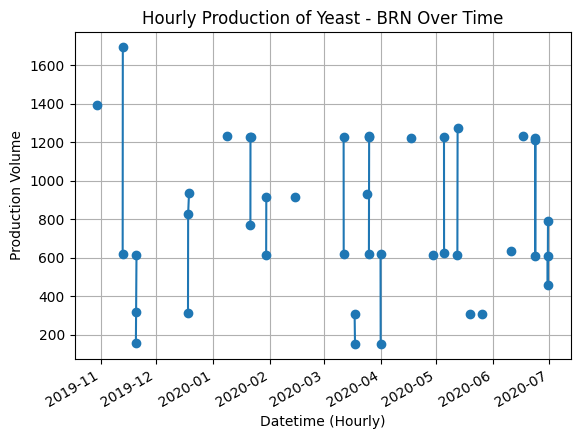

<Figure size 1000x600 with 0 Axes>

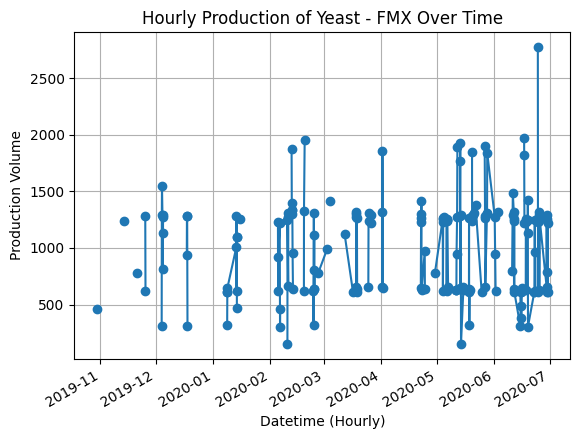

In [26]:
# Create individual plots for each product
products = ['Yeast - BRD', 'Yeast - BRN', 'Yeast - FMX']

for product in products:
    plt.figure(figsize=(10, 6))
    merged_df[[product]].plot(kind='line', marker='o', legend=False)
    plt.title(f'Hourly Production of {product} Over Time')
    plt.xlabel('Datetime (Hourly)')
    plt.ylabel('Production Volume')
    plt.grid(True)
    plt.show()

In [27]:
file_path = "../Data Processing/daily_sum_weight_merg_2.csv"




In [55]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# Load and preprocess the data
df = pd.read_csv(file_path)
df.fillna(0, inplace=True)
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.set_index('Datetime', inplace=True)

# Select target columns and additional input features
target_columns = ['Yeast - BRD', 'Yeast - BRN', 'Yeast - FMX']
additional_features = ['Yeast - BRD_Yield', 'Yeast - BRD_VMBX_Feed', 'Yeast - BRD_Papain', 'Yeast - BRD_Volume', 
                   'Yeast - BRD_VFX_Feed', 'Yeast - BRD_IS/TS', 'Yeast - BRN_Yield', 'Yeast - BRN_VMBX_Feed', 'Yeast - BRN_Papain', 'Yeast - BRN_Volume', 
                   'Yeast - BRN_VFX_Feed', 'Yeast - BRN_IS/TS', 'Yeast - FMX_Yield', 'Yeast - FMX_VMBX_Feed', 'Yeast - FMX_Papain', 'Yeast - FMX_Volume', 
                   'Yeast - FMX_VFX_Feed', 'Yeast - FMX_IS/TS']

# Separate the target data and additional input data
target_data = df[target_columns].values
additional_input_data = df[additional_features].values

# Scaling the target columns and additional features separately
target_scaler = MinMaxScaler(feature_range=(0, 1))
additional_scaler = MinMaxScaler(feature_range=(0, 1))

scaled_target_data = target_scaler.fit_transform(target_data)
scaled_additional_data = additional_scaler.fit_transform(additional_input_data)

# Create dataset with look-back
def create_dataset_for_xgboost(dataset, additional_data, look_back):
    X, Y, additional = [], [], []
    for i in range(len(dataset) - look_back - 1):
        X.append(dataset[i:(i + look_back)])  # Target columns as input
        Y.append(dataset[i + look_back])      # Predict the next timestep of the target
        additional.append(additional_data[i + look_back])  # Additional features for the last timestep
    return np.array(X), np.array(Y), np.array(additional)

look_back = 30
X, Y, additional = create_dataset_for_xgboost(scaled_target_data, scaled_additional_data, look_back)

# Reshape input to be [samples, time steps, features]
X = np.reshape(X, (X.shape[0], look_back, X.shape[2]))

# Split into train and test sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
Y_train, Y_test = Y[:train_size], Y[train_size:]
additional_train, additional_test = additional[:train_size], additional[train_size:]

# Flatten the inputs for XGBoost
X_train_flat = np.array([np.concatenate([x.flatten(), add]) for x, add in zip(X_train, additional_train)])
X_test_flat = np.array([np.concatenate([x.flatten(), add]) for x, add in zip(X_test, additional_test)])

# Train an XGBoost model for each target variable
models = []
for i in range(Y_train.shape[1]):  # Iterate over each target column
    model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.05, max_depth=5)
    model.fit(X_train_flat, Y_train[:, i])
    models.append(model)

# Make predictions
test_predictions = np.column_stack([model.predict(X_test_flat) for model in models])

scaled_test_predictions = target_scaler.inverse_transform(test_predictions)
scaled_Y_test = target_scaler.inverse_transform(Y_test)

# Compute error


X_train_flat shape: (220, 108)
X_test_flat shape: (55, 108)
Y_train shape: (220, 3)
Number of models: 3
Number of features: 108

=== SHAP Analysis for Yeast - BRD Model ===


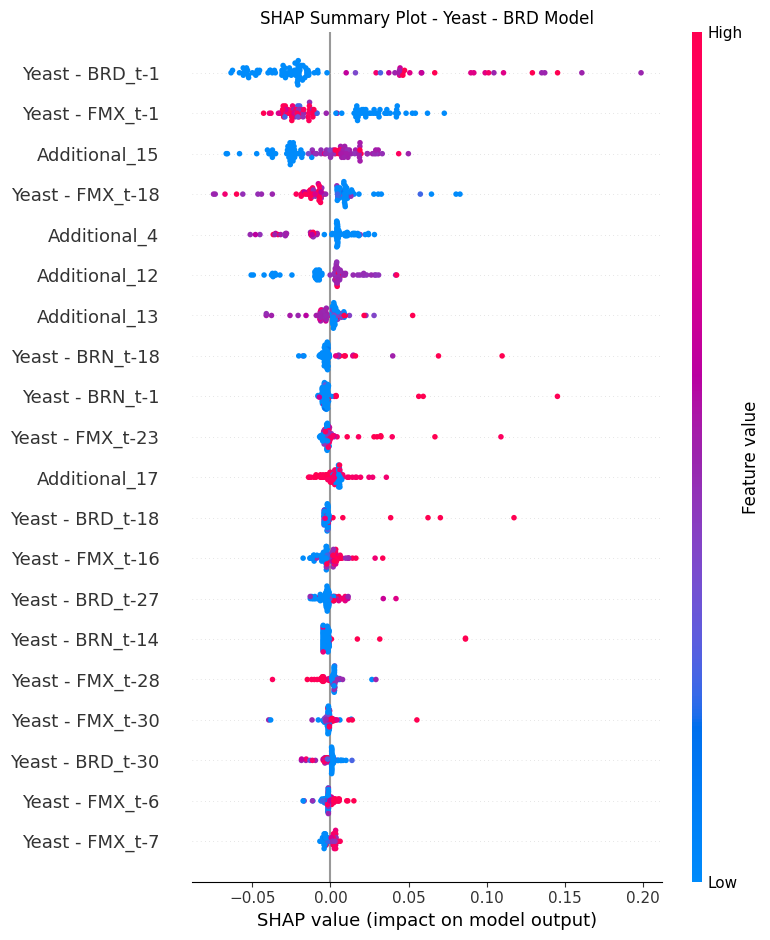

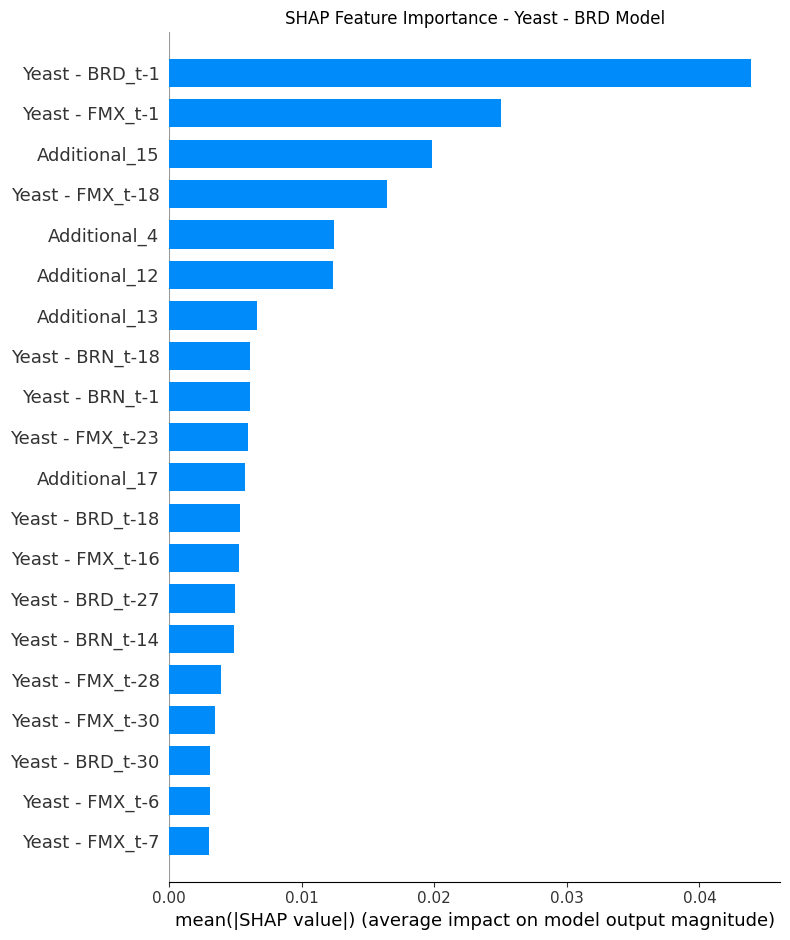


=== LIME Analysis ===

--- LIME Explanation for Test Instance 0 ---


<Figure size 1000x600 with 0 Axes>

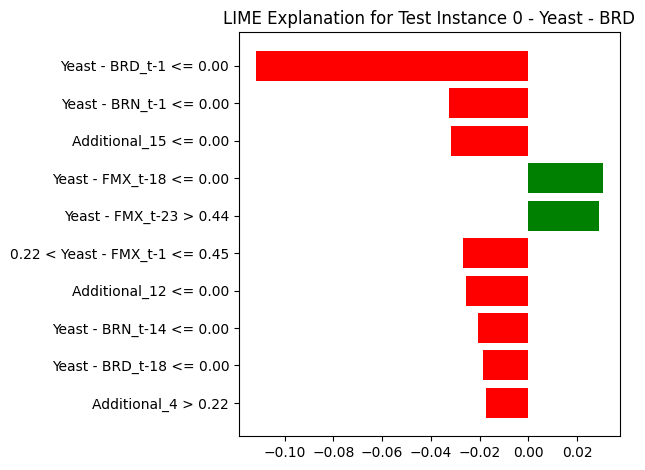

Feature weights:
Yeast - BRD_t-1 <= 0.00: -0.1117
Yeast - BRN_t-1 <= 0.00: -0.0327
Additional_15 <= 0.00: -0.0316
Yeast - FMX_t-18 <= 0.00: 0.0305
Yeast - FMX_t-23 > 0.44: 0.0291
0.22 < Yeast - FMX_t-1 <= 0.45: -0.0266
Additional_12 <= 0.00: -0.0255
Yeast - BRN_t-14 <= 0.00: -0.0208
Yeast - BRD_t-18 <= 0.00: -0.0188
Additional_4 > 0.22: -0.0175

--- LIME Explanation for Test Instance 1 ---


<Figure size 1000x600 with 0 Axes>

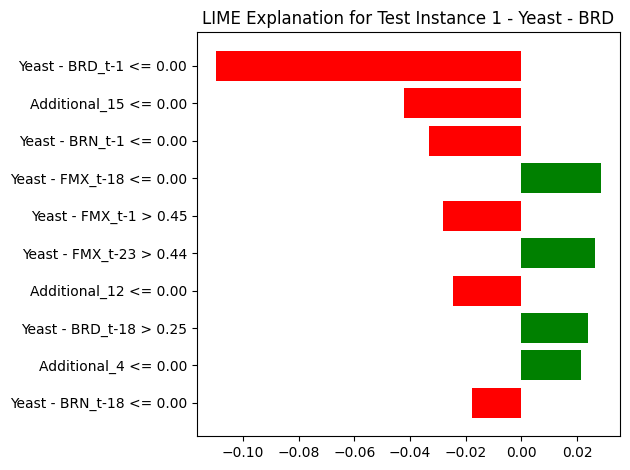

Feature weights:
Yeast - BRD_t-1 <= 0.00: -0.1096
Additional_15 <= 0.00: -0.0420
Yeast - BRN_t-1 <= 0.00: -0.0333
Yeast - FMX_t-18 <= 0.00: 0.0285
Yeast - FMX_t-1 > 0.45: -0.0283
Yeast - FMX_t-23 > 0.44: 0.0264
Additional_12 <= 0.00: -0.0245
Yeast - BRD_t-18 > 0.25: 0.0239
Additional_4 <= 0.00: 0.0215
Yeast - BRN_t-18 <= 0.00: -0.0176

--- LIME Explanation for Test Instance 2 ---


<Figure size 1000x600 with 0 Axes>

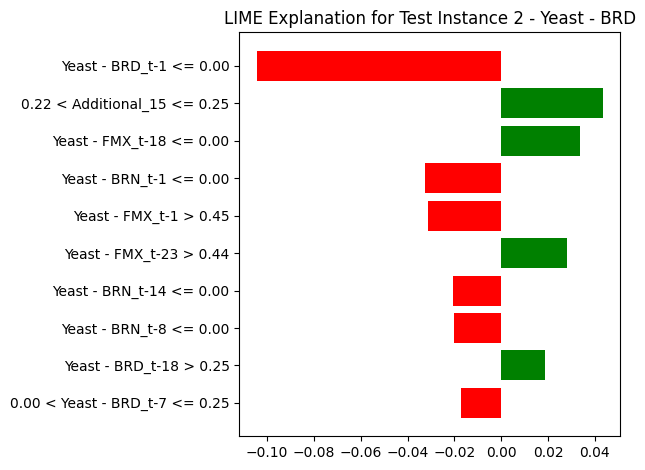

Feature weights:
Yeast - BRD_t-1 <= 0.00: -0.1044
0.22 < Additional_15 <= 0.25: 0.0433
Yeast - FMX_t-18 <= 0.00: 0.0335
Yeast - BRN_t-1 <= 0.00: -0.0324
Yeast - FMX_t-1 > 0.45: -0.0314
Yeast - FMX_t-23 > 0.44: 0.0280
Yeast - BRN_t-14 <= 0.00: -0.0206
Yeast - BRN_t-8 <= 0.00: -0.0200
Yeast - BRD_t-18 > 0.25: 0.0187
0.00 < Yeast - BRD_t-7 <= 0.25: -0.0173

=== Feature Importance Analysis Across All Models ===

--- Yeast - BRD Model ---
Top 10 most important features:
Additional_12: 0.1612
Additional_4: 0.0861
Yeast - BRD_t-1: 0.0560
Yeast - FMX_t-1: 0.0508
Yeast - FMX_t-18: 0.0434
Yeast - BRN_t-1: 0.0251
Additional_15: 0.0208
Yeast - BRN_t-10: 0.0204
Yeast - FMX_t-23: 0.0204
Yeast - BRD_t-27: 0.0175


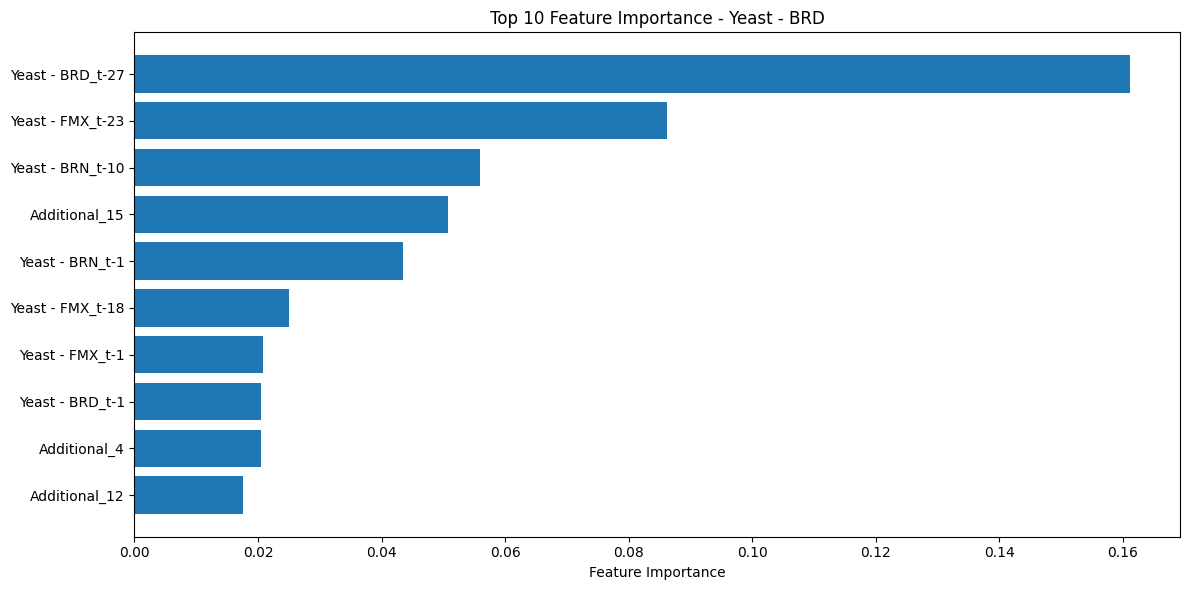


--- Yeast - BRN Model ---
Top 10 most important features:
Yeast - FMX_t-15: 0.0750
Yeast - BRN_t-1: 0.0581
Yeast - FMX_t-11: 0.0523
Yeast - BRN_t-6: 0.0522
Yeast - FMX_t-5: 0.0458
Yeast - BRD_t-2: 0.0409
Yeast - BRN_t-21: 0.0382
Yeast - BRD_t-16: 0.0366
Yeast - BRD_t-10: 0.0351
Yeast - FMX_t-9: 0.0313


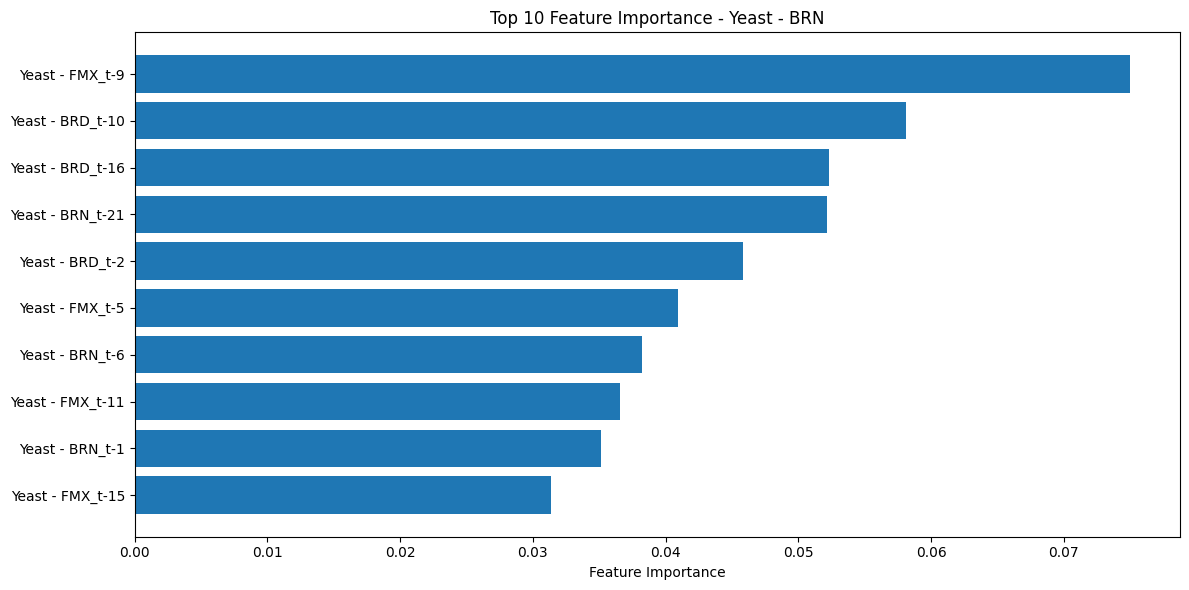


--- Yeast - FMX Model ---
Top 10 most important features:
Yeast - FMX_t-1: 0.0660
Yeast - BRN_t-13: 0.0425
Yeast - BRN_t-2: 0.0345
Yeast - BRD_t-24: 0.0319
Yeast - BRN_t-19: 0.0312
Yeast - BRN_t-20: 0.0307
Yeast - BRD_t-18: 0.0246
Additional_12: 0.0242
Additional_1: 0.0233
Additional_7: 0.0210


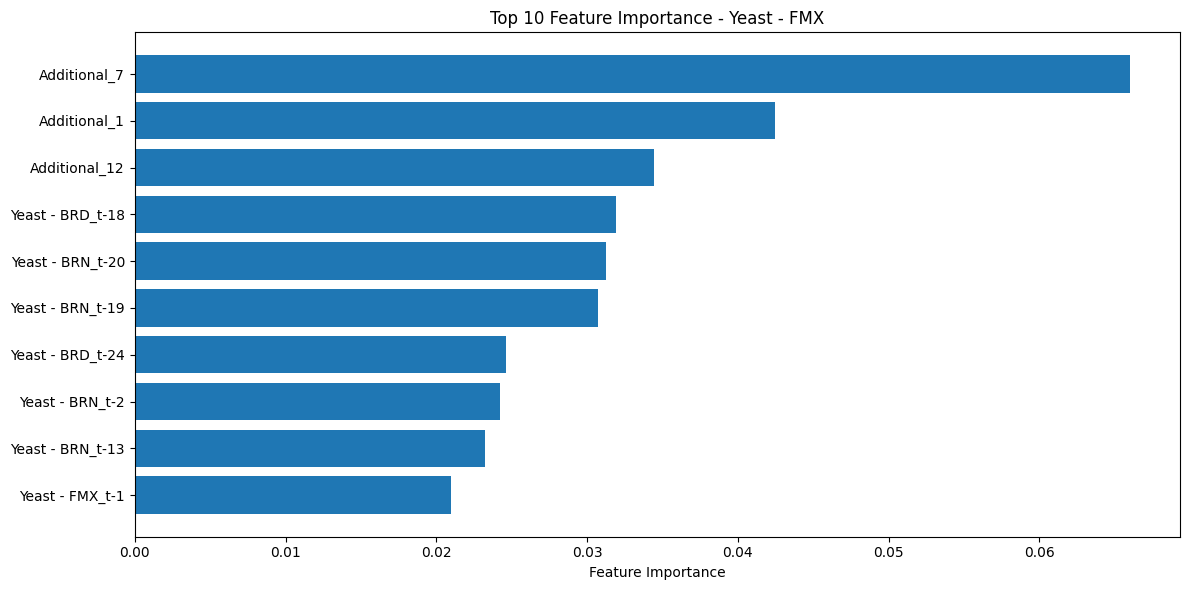


=== Time-based Feature Analysis ===


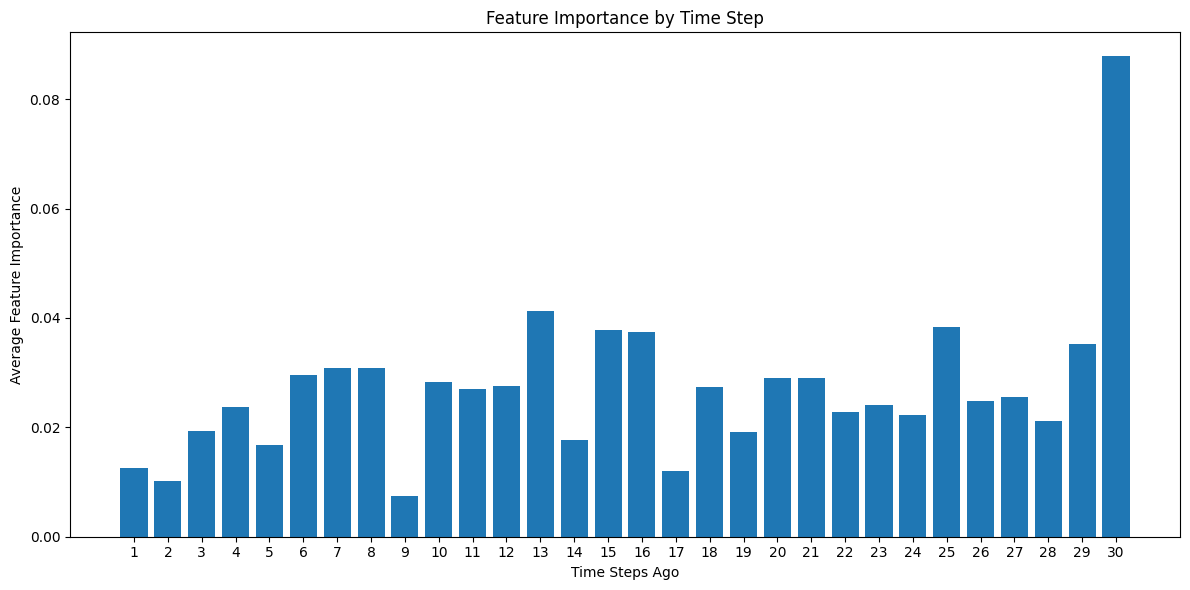

Time step importance (1 = most recent):
t-1: 0.0126
t-2: 0.0101
t-3: 0.0193
t-4: 0.0238
t-5: 0.0167
t-6: 0.0296
t-7: 0.0308
t-8: 0.0308
t-9: 0.0074
t-10: 0.0283
t-11: 0.0269
t-12: 0.0275
t-13: 0.0412
t-14: 0.0178
t-15: 0.0379
t-16: 0.0375
t-17: 0.0120
t-18: 0.0273
t-19: 0.0191
t-20: 0.0291
t-21: 0.0290
t-22: 0.0228
t-23: 0.0241
t-24: 0.0223
t-25: 0.0384
t-26: 0.0249
t-27: 0.0255
t-28: 0.0212
t-29: 0.0352
t-30: 0.0878

=== Additional Features Importance ===


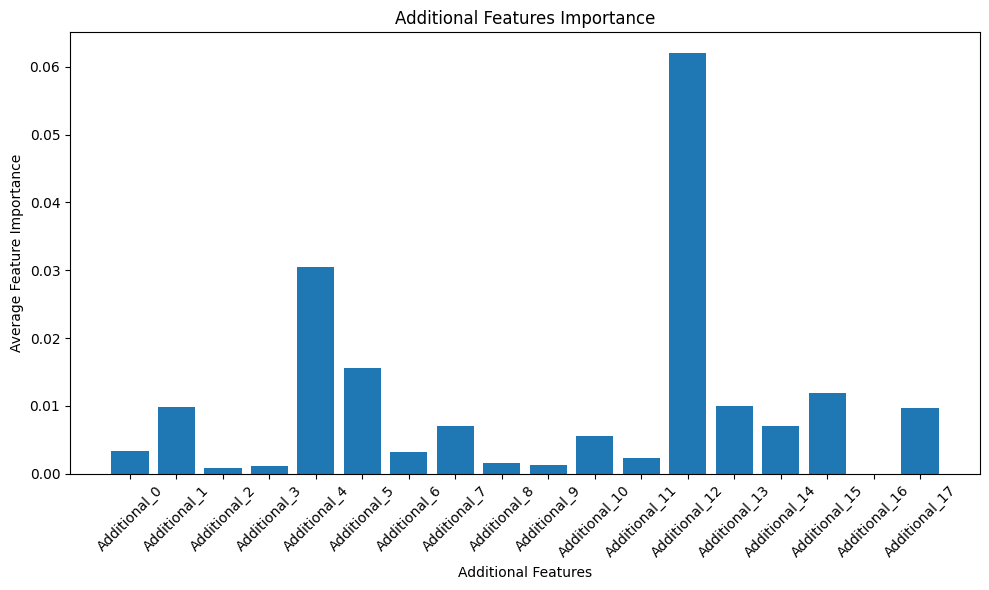

Additional features importance:
Additional_0: 0.0033
Additional_1: 0.0099
Additional_2: 0.0009
Additional_3: 0.0011
Additional_4: 0.0305
Additional_5: 0.0156
Additional_6: 0.0032
Additional_7: 0.0070
Additional_8: 0.0016
Additional_9: 0.0013
Additional_10: 0.0056
Additional_11: 0.0024
Additional_12: 0.0620
Additional_13: 0.0100
Additional_14: 0.0071
Additional_15: 0.0119
Additional_16: 0.0000
Additional_17: 0.0097


In [58]:
import shap
import lime
import lime.lime_tabular
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# First, let's understand the dimensions of our data
print(f"X_train_flat shape: {X_train_flat.shape}")
print(f"X_test_flat shape: {X_test_flat.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Number of models: {len(models)}")

# Create feature names for better interpretability
# Each timestep has target features + additional features
target_feature_names = ['Yeast - BRD', 'Yeast - BRN', 'Yeast - FMX']
additional_feature_names = [f'Additional_{i}' for i in range(additional_train.shape[1])]

# Create feature names for the flattened input
feature_names = []
for t in range(look_back):
    for target in target_feature_names:
        feature_names.append(f'{target}_t-{look_back-t}')
for add_feat in additional_feature_names:
    feature_names.append(add_feat)

print(f"Number of features: {len(feature_names)}")

# SHAP Analysis for the first model (Yeast - BRD)
print("\n=== SHAP Analysis for Yeast - BRD Model ===")

# Use a subset of data for SHAP analysis (it can be computationally expensive)
shap_sample_size = min(100, X_train_flat.shape[0])
shap_sample_indices = np.random.choice(X_train_flat.shape[0], shap_sample_size, replace=False)
X_shap_sample = X_train_flat[shap_sample_indices]

# Create SHAP explainer
explainer = shap.TreeExplainer(models[0])
shap_values = explainer.shap_values(X_shap_sample)

# Plot SHAP summary
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap_sample, feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot - Yeast - BRD Model')
plt.tight_layout()
plt.show()

# Plot SHAP bar plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap_sample, feature_names=feature_names, plot_type="bar", show=False)
plt.title('SHAP Feature Importance - Yeast - BRD Model')
plt.tight_layout()
plt.show()

# LIME Analysis
print("\n=== LIME Analysis ===")

# Create LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_flat,
    feature_names=feature_names,
    class_names=['Yeast - BRD'],
    mode='regression'
)

# Explain a few test instances
for i in range(min(3, len(X_test_flat))):
    print(f"\n--- LIME Explanation for Test Instance {i} ---")
    
    # Get LIME explanation
    exp = lime_explainer.explain_instance(
        X_test_flat[i], 
        models[0].predict, 
        num_features=10,
        num_samples=1000
    )
    
    # Plot LIME explanation
    plt.figure(figsize=(10, 6))
    exp.as_pyplot_figure()
    plt.title(f'LIME Explanation for Test Instance {i} - Yeast - BRD')
    plt.tight_layout()
    plt.show()
    
    # Print feature weights
    print("Feature weights:")
    for feat, weight in exp.as_list():
        print(f"{feat}: {weight:.4f}")

# Analyze feature importance across all models
print("\n=== Feature Importance Analysis Across All Models ===")

for i, (model, target_name) in enumerate(zip(models, target_feature_names)):
    print(f"\n--- {target_name} Model ---")
    
    # Get feature importance from XGBoost
    importance = model.feature_importances_
    top_features_idx = np.argsort(importance)[-10:]  # Top 10 features
    
    print("Top 10 most important features:")
    for idx in reversed(top_features_idx):
        print(f"{feature_names[idx]}: {importance[idx]:.4f}")
    
    # Plot feature importance
    plt.figure(figsize=(12, 6))
    plt.barh(range(10), importance[top_features_idx])
    plt.yticks(range(10), [feature_names[idx] for idx in reversed(top_features_idx)])
    plt.xlabel('Feature Importance')
    plt.title(f'Top 10 Feature Importance - {target_name}')
    plt.tight_layout()
    plt.show()

# Time-based feature analysis
print("\n=== Time-based Feature Analysis ===")

# Analyze which time steps are most important
time_importance = np.zeros(look_back)
for i, model in enumerate(models):
    importance = model.feature_importances_
    for t in range(look_back):
        # Sum importance of features from this time step
        start_idx = t * len(target_feature_names)
        end_idx = start_idx + len(target_feature_names)
        time_importance[t] += np.sum(importance[start_idx:end_idx])

time_importance /= len(models)  # Average across models

plt.figure(figsize=(12, 6))
plt.bar(range(1, look_back + 1), time_importance)
plt.xlabel('Time Steps Ago')
plt.ylabel('Average Feature Importance')
plt.title('Feature Importance by Time Step')
plt.xticks(range(1, look_back + 1))
plt.tight_layout()
plt.show()

print("Time step importance (1 = most recent):")
for t, imp in enumerate(time_importance, 1):
    print(f"t-{t}: {imp:.4f}")

# Additional features importance
print("\n=== Additional Features Importance ===")
additional_start_idx = look_back * len(target_feature_names)
additional_importance = np.zeros(len(additional_feature_names))

for i, model in enumerate(models):
    importance = model.feature_importances_
    additional_importance += importance[additional_start_idx:]

additional_importance /= len(models)

plt.figure(figsize=(10, 6))
plt.bar(range(len(additional_feature_names)), additional_importance)
plt.xlabel('Additional Features')
plt.ylabel('Average Feature Importance')
plt.title('Additional Features Importance')
plt.xticks(range(len(additional_feature_names)), additional_feature_names, rotation=45)
plt.tight_layout()
plt.show()

print("Additional features importance:")
for feat, imp in zip(additional_feature_names, additional_importance):
    print(f"{feat}: {imp:.4f}")


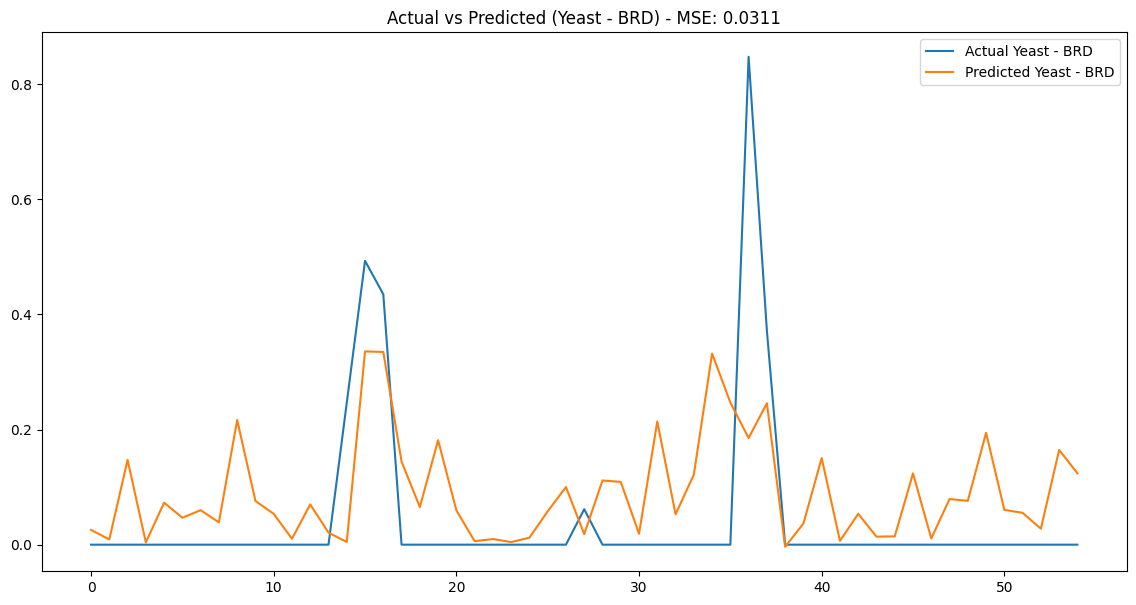

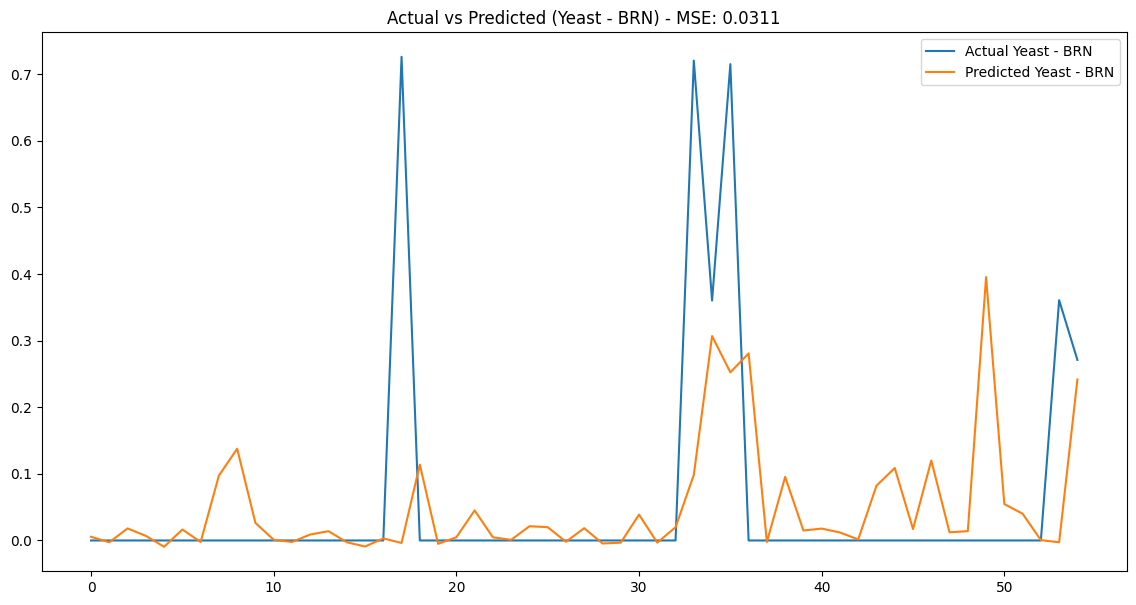

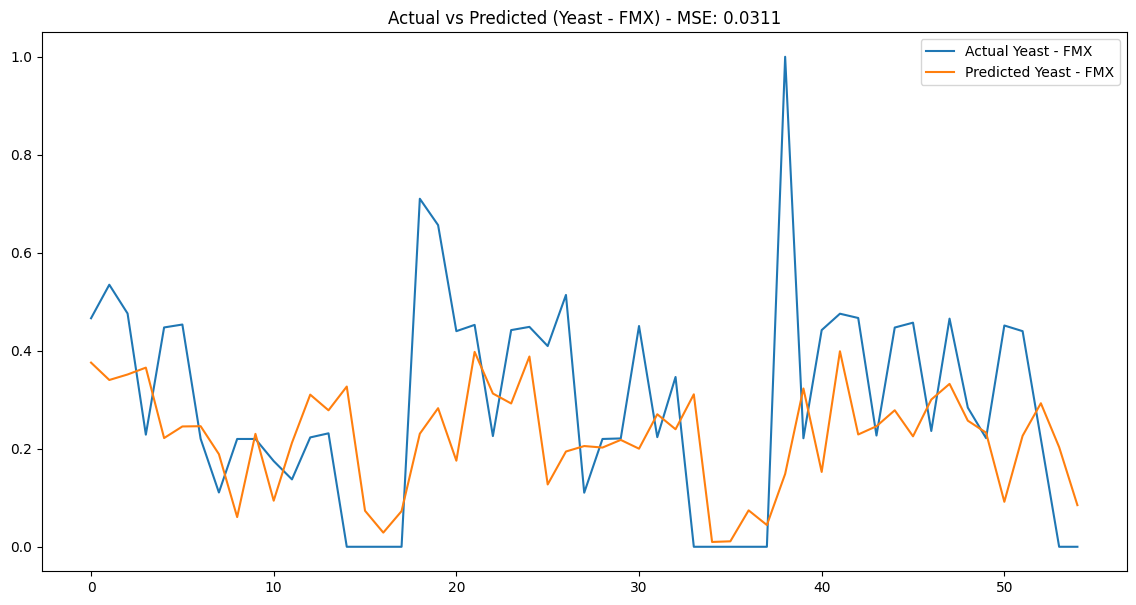

In [29]:
mse = mean_squared_error(Y_test, test_predictions)

# Plot actual vs predicted for each target column
plt.figure(figsize=(14, 7))
plt.plot(Y_test[:, 0], label='Actual Yeast - BRD')
plt.plot(test_predictions[:, 0], label='Predicted Yeast - BRD')
plt.title(f'Actual vs Predicted (Yeast - BRD) - MSE: {mse:.4f}')
plt.legend()
plt.show()

plt.figure(figsize=(14, 7))
plt.plot(Y_test[:, 1], label='Actual Yeast - BRN')
plt.plot(test_predictions[:, 1], label='Predicted Yeast - BRN')
plt.title(f'Actual vs Predicted (Yeast - BRN) - MSE: {mse:.4f}')
plt.legend()
plt.show()

plt.figure(figsize=(14, 7))
plt.plot(Y_test[:, 2], label='Actual Yeast - FMX')
plt.plot(test_predictions[:, 2], label='Predicted Yeast - FMX')
plt.title(f'Actual vs Predicted (Yeast - FMX) - MSE: {mse:.4f}')
plt.legend()
plt.show()



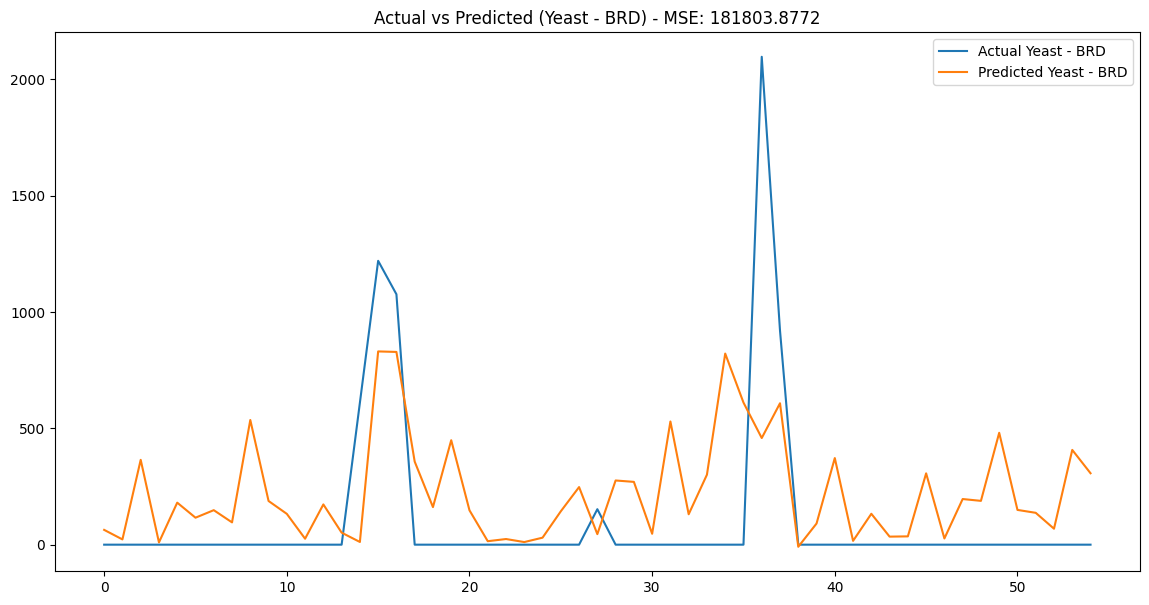

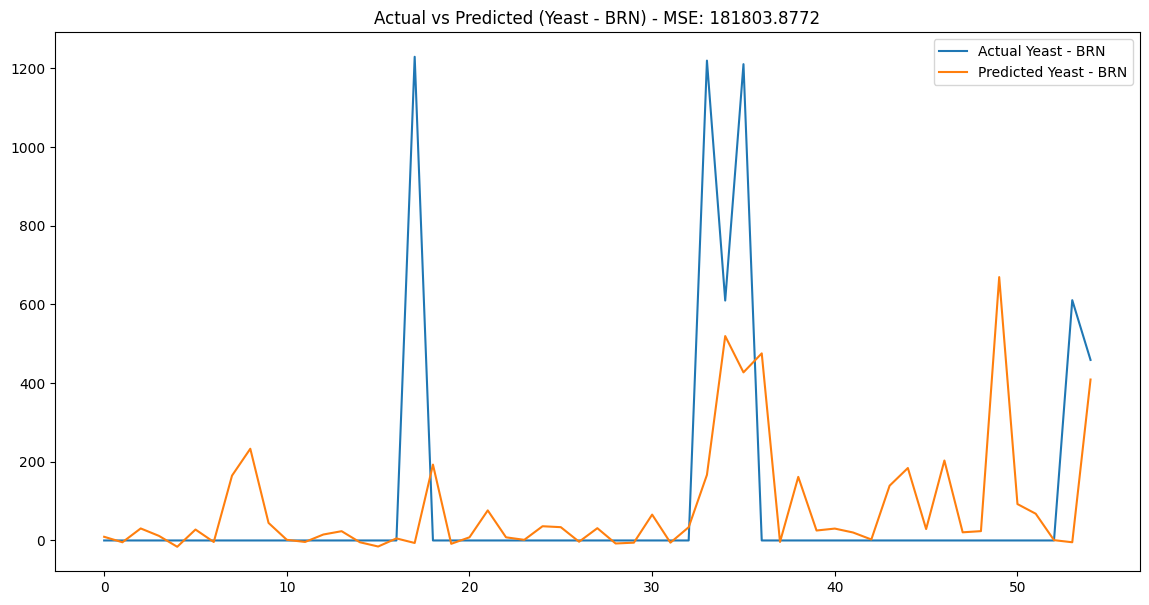

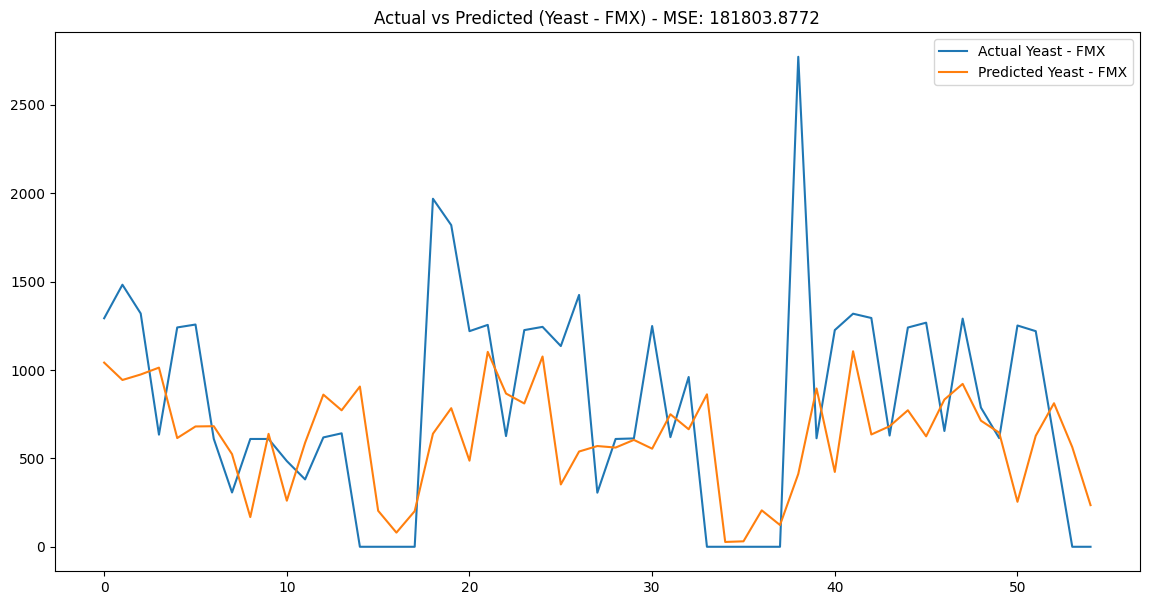

In [30]:
mse = mean_squared_error(scaled_Y_test, scaled_test_predictions)

# Plot actual vs predicted for each target column
plt.figure(figsize=(14, 7))
plt.plot(scaled_Y_test[:, 0], label='Actual Yeast - BRD')
plt.plot(scaled_test_predictions[:, 0], label='Predicted Yeast - BRD')
plt.title(f'Actual vs Predicted (Yeast - BRD) - MSE: {mse:.4f}')
plt.legend()
plt.show()

plt.figure(figsize=(14, 7))
plt.plot(scaled_Y_test[:, 1], label='Actual Yeast - BRN')
plt.plot(scaled_test_predictions[:, 1], label='Predicted Yeast - BRN')
plt.title(f'Actual vs Predicted (Yeast - BRN) - MSE: {mse:.4f}')
plt.legend()
plt.show()

plt.figure(figsize=(14, 7))
plt.plot(scaled_Y_test[:, 2], label='Actual Yeast - FMX')
plt.plot(scaled_test_predictions[:, 2], label='Predicted Yeast - FMX')
plt.title(f'Actual vs Predicted (Yeast - FMX) - MSE: {mse:.4f}')
plt.legend()
plt.show()



In [32]:

# Extract the dates for the test data (this assumes your DataFrame has 'Datetime' as the index)
dates = df.index[-len(scaled_Y_test):]  # Adjust the range based on your test set size

# Create the DataFrame with Date & Hour, Current (Actual), and Predicted values
output_df = pd.DataFrame({
    'Date & hour': dates,
    'Current Yeast - BRD': scaled_Y_test[:, 0],
    'Predicted Yeast - BRD': scaled_test_predictions[:, 0],
    'Current Yeast - BRN': scaled_Y_test[:, 1],
    'Predicted Yeast - BRN': scaled_test_predictions[:, 1],
    'Current Yeast - FMX': scaled_Y_test[:, 2],
    'Predicted Yeast - FMX': scaled_test_predictions[:, 2],
})

# Save the DataFrame to a CSV file
output_file_path = '../Data Processing/xgboost_predictions_v2_output-hours.csv'  # Change this path if needed
output_df.to_csv(output_file_path, index=False)


(30, 3)